In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
import os

base_path = "../Check_data"
all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)


In [37]:
# trim the first 3 seconds and the last 3
def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

# ID als separate Spalte sichern bevor groupby sie verschluckt
final_df["ID_backup"] = final_df["ID"]

df = (
    final_df
    .groupby("ID_backup", group_keys=False)
    .apply(trim_measurement)
    .reset_index(drop=True)
)


In [38]:
df.head()

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
0,2026-03-19 06:20:14.221760000,3.091760,-3.749366,4.319229,3.509879,Accelerometer,Velo,0
1,2026-03-19 06:20:14.230093000,3.100093,2.779958,-1.853551,0.228387,Accelerometer,Velo,0
2,2026-03-19 06:20:14.238426000,3.108426,3.345988,-6.905356,-1.106222,Accelerometer,Velo,0
3,2026-03-19 06:20:14.246759200,3.116759,1.655410,-7.704383,-1.403258,Accelerometer,Velo,0
4,2026-03-19 06:20:14.255092200,3.125092,0.940845,-7.069280,-2.639094,Accelerometer,Velo,0


In [39]:
# Check if every ID has a Tag
df.groupby(["ID"]).Tag.apply(lambda x: x.isna().any())

ID
0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: Tag, dtype: bool

In [40]:
df.groupby("ID")["Tag"].unique()

ID
0    [Velo]
1    [Velo]
2    [Velo]
3    [Velo]
4    [Lift]
5    [Lift]
6    [Lift]
7    [Velo]
8    [Velo]
9    [Velo]
Name: Tag, dtype: object

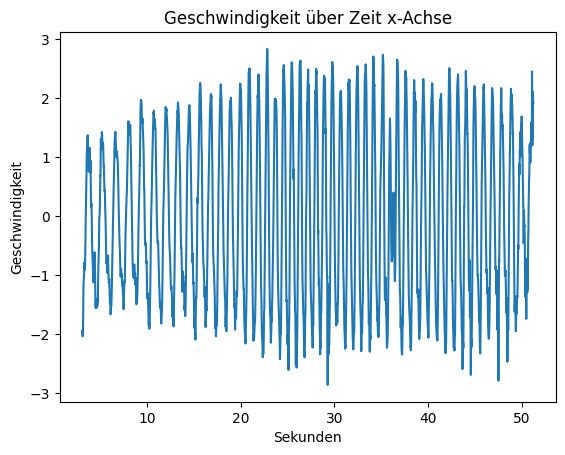

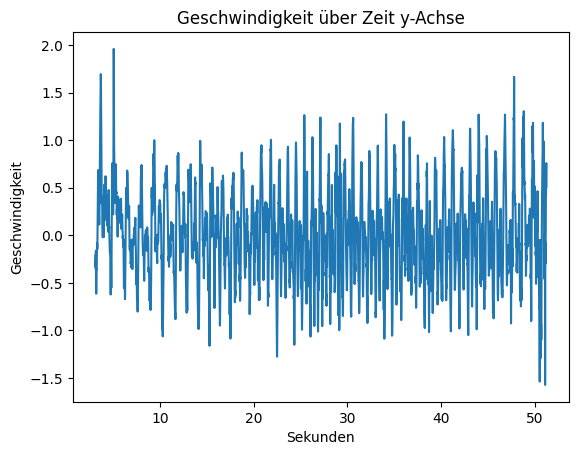

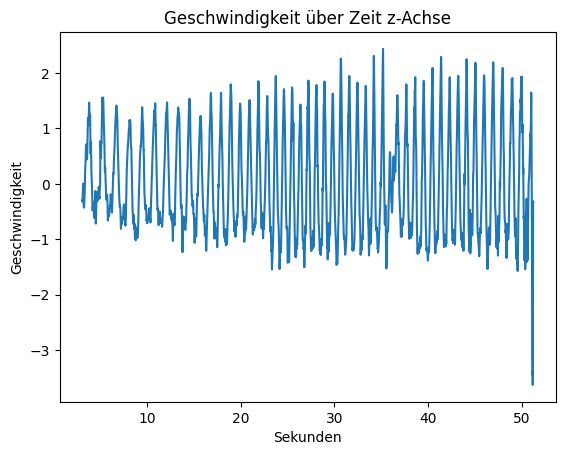

In [41]:
speed = df[(df["Sensor"] == "Gyroscope") & (df['ID'] == 9)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()